# Cloud Masking Maxar Imagery

This notebook shows how to download a Maxar open-data scene and generate a cloud mask using OmniCloudMask.

Maxar multispectral images come in 4-band (RGBN) or 8-band configurations — OmniCloudMask handles both by detecting the band count and selecting the correct Red, Green, and NIR channels.

Sample URLs are available at [maxar.com/open-data](https://www.maxar.com/open-data/).

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import rasterio as rio
import requests
from rasterio.enums import Resampling
from tqdm.auto import tqdm

from omnicloudmask import predict_from_array

## 1. Download a Maxar scene

Paste a Maxar open-data multispectral URL below. The file is cached locally so re-running the cell skips the download.

In [2]:
url = "https://maxar-opendata.s3.us-west-2.amazonaws.com/events/Emilia-Romagna-Italy-flooding-may23/ard/32/120000303231/2023-05-23/1050010033C95B00-ms.tif"
# url = "https://maxar-opendata.s3.us-west-2.amazonaws.com/events/tonga-volcano21/ard/01/300222121030/2022-01-18/1040010071C26C00-ms.tif"
# url = "https://maxar-opendata.s3.us-west-2.amazonaws.com/events/Hurricane-Ian-9-26-2022/ard/17/031331321021/2022-10-01/104001007C700900-ms.tif"

file_name = "_".join(url.split("/")[-3:])
scene_path = Path.cwd() / f"Maxar data/{file_name}"
scene_path.parent.mkdir(exist_ok=True, parents=True)

if not scene_path.exists():
    print(f"Downloading to {scene_path}")
    with requests.get(url, stream=True) as response:
        total = int(response.headers["Content-Length"])
        with (
            open(scene_path, "wb") as f,
            tqdm(unit="B", unit_scale=True, total=total) as pbar,
        ):
            for chunk in response.iter_content(chunk_size=8192):
                f.write(chunk)
                pbar.update(len(chunk))
else:
    print(f"Already downloaded: {scene_path}")

Already downloaded: /Users/nick/Documents/Work Code/OmniCloudMask/examples/Maxar data/120000303231_2023-05-23_1050010033C95B00-ms.tif


## 2. Load bands

Maxar imagery is natively ~50 cm resolution. OmniCloudMask works at 10–50 m, so we resample to 10 m on read.

Band layout depends on whether the scene has 4 or 8 channels:
- **4-band**: R, G, B, NIR (bands 1–4)
- **8-band**: coastal, blue, green, yellow, red, red-edge, NIR1, NIR2 — we use bands 5 (R), 3 (G), 2 (B), 8 (NIR)

We load RGB for visualisation and RGN for inference.

In [3]:
TARGET_RES = 10  # metres

with rio.open(scene_path) as src:
    channel_count = src.count
    if channel_count == 4:
        print("4-band scene (RGBN)")
        band_indices = [1, 2, 3, 4]  # R, G, B, NIR
    else:
        print("8-band scene")
        band_indices = [5, 3, 2, 8]  # R, G, B, NIR

    scale = src.res[0] / TARGET_RES
    out_shape = (4, int(src.height * scale), int(src.width * scale))
    rgbn = src.read(band_indices, out_shape=out_shape, resampling=Resampling.bilinear)

rgb = rgbn[:3]  # R, G, B  — for display
scene = rgbn[[0, 1, 3]]  # R, G, NIR — for OmniCloudMask
print(f"Scene shape: {scene.shape}")

4-band scene (RGBN)
Scene shape: (3, 531, 531)


## 3. Run OmniCloudMask

In [4]:
mask = predict_from_array(scene)
print(f"Mask shape: {mask.shape}")
print("Classes — 0: clear, 1: thick cloud, 2: thin cloud, 3: cloud shadow")

/Users/nick/Documents/Work Code/OmniCloudMask/omnicloudmask/cloud_mask.py:274: UserWarning: Patch size too large, reducing to 531 and overlap to 265.
  patch_overlap, patch_size = check_patch_size(


Mask shape: (1, 531, 531)
Classes — 0: clear, 1: thick cloud, 2: thin cloud, 3: cloud shadow


## 4. Visualise

Three panels: true-colour RGB, the raw class mask, and an overlay where non-clear pixels are shown at 40% opacity.

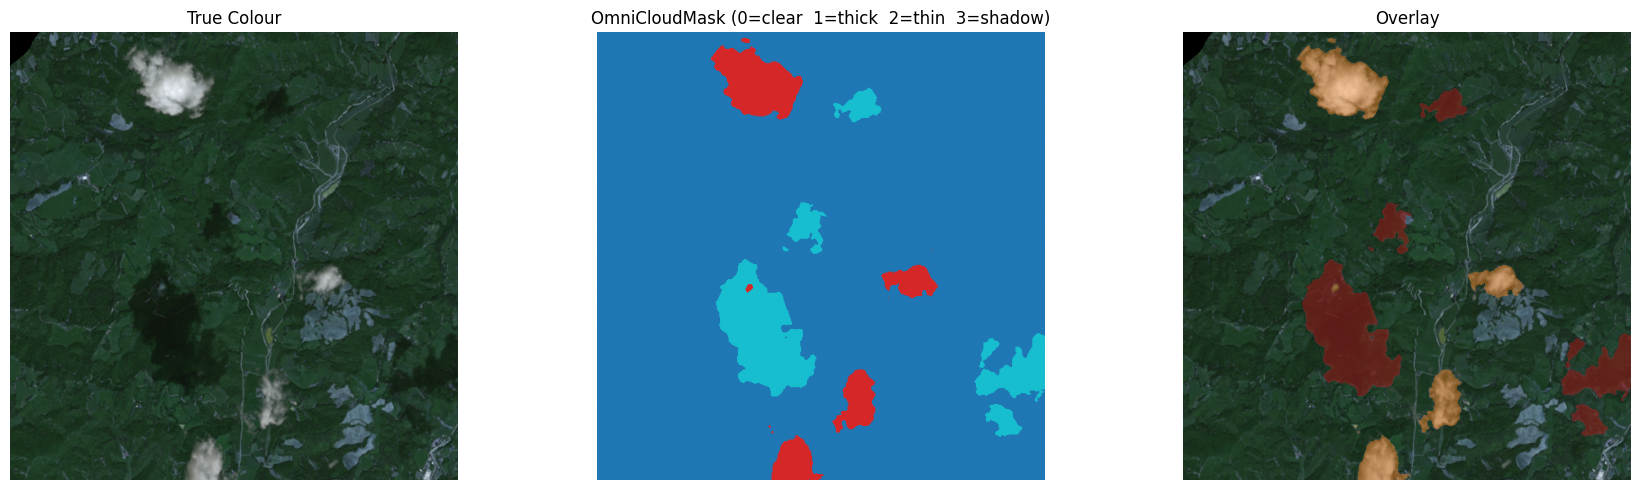

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

rgb_display = np.power(rgb.astype("float32"), 0.5)
rgb_display = (rgb_display - rgb_display.min()) / (
    rgb_display.max() - rgb_display.min()
)
rgb_display = np.clip(rgb_display, 0, 1).transpose(1, 2, 0)

axes[0].imshow(rgb_display)
axes[0].set_title("True Colour")
axes[0].axis("off")

axes[1].imshow(mask.squeeze(), cmap="tab10", vmin=0, vmax=3)
axes[1].set_title("OmniCloudMask (0=clear  1=thick  2=thin  3=shadow)")
axes[1].axis("off")

tab10 = plt.get_cmap("tab10")
mask_sq = mask.squeeze()
rgba = np.zeros((*mask_sq.shape, 4), dtype=float)
for cls in range(4):
    colour = tab10(cls / 9)
    where = mask_sq == cls
    rgba[where, :3] = colour[:3]
    rgba[where, 3] = 0.0 if cls == 0 else 0.4

axes[2].imshow(rgb_display)
axes[2].imshow(rgba)
axes[2].set_title("Overlay")
axes[2].axis("off")

plt.tight_layout()
plt.show()

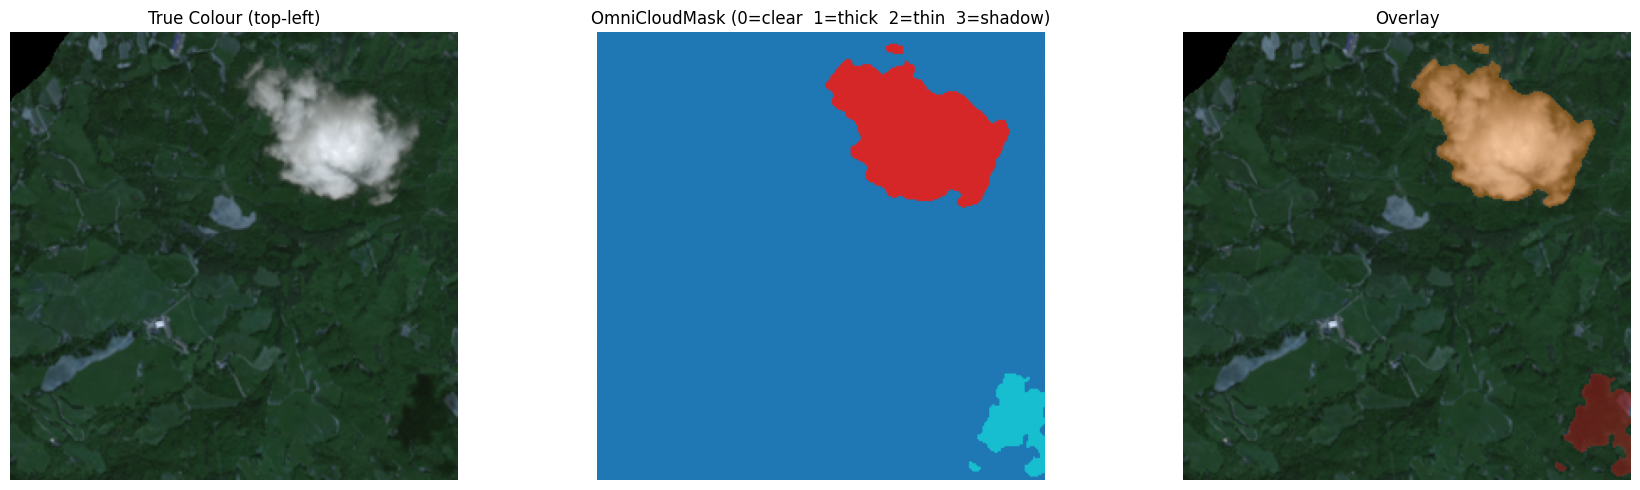

In [6]:
# Zoom into the top-left quarter
h, w = mask_sq.shape
rs, re, cs, ce = 0, h // 2, 0, w // 2

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(rgb_display[rs:re, cs:ce])
axes[0].set_title("True Colour (top-left)")
axes[0].axis("off")
axes[1].imshow(mask_sq[rs:re, cs:ce], cmap="tab10", vmin=0, vmax=3)
axes[1].set_title("OmniCloudMask (0=clear  1=thick  2=thin  3=shadow)")
axes[1].axis("off")
axes[2].imshow(rgb_display[rs:re, cs:ce])
axes[2].imshow(rgba[rs:re, cs:ce])
axes[2].set_title("Overlay")
axes[2].axis("off")
plt.tight_layout()
plt.show()